# BigAlpha 2026 端到端 V1 — 5m 原始 bar 序列 Transformer

**输入**: 每(股票,日) 最近 5 个交易日 × 48 根 5m bar × 25 个原始量价/盘口字段 (仅 bigalpha_2026_stock_bar5m)
**模型**: Transformer 6层/d256/8头/ffn1024, 可训练参数 4,823,681 (无外部预训练权重, 种子固定 42)
**标签**: 未来20日累计复权收益, 按日截面 1%/99% winsorize + zscore
**预处理**: 缺失填充 + 按字段 log/log1p + 按字段全局标准化(仅训练集统计) — 无任何衍生特征

提交文件: 本 notebook + `bigalpha_v1.py` (训练/推理共用) + `bigalpha_v1_model.json` (fp16 权重经 base64 编码的 JSON 文本, 由 `train_and_save` 产出)
- 公榜: 平台替换 datasources/start_date/end_date 调用 `main`, 加载权重只推理
- 私榜: 平台调用 `bigalpha_v1.train_and_save(datasources)` 从零重训

In [1]:
import os
from bigalpha_v1 import main, train_and_save, MODEL_JSON

# 只用 5 分钟 K 线+盘口作为输入数据
datasources = {"bar5m": "bigalpha_2026_stock_bar5m"}

# 兜底: 若权重文件不存在则从零训练 (正式流程为本地/私榜运行 train_and_save)
if not os.path.exists(MODEL_JSON):
    train_and_save(datasources)

# 平台注入测试区间; 本地调试用 2024 公榜验证集
start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
score_data = main(datasources, start_date, end_date)
print(score_data.head())

query 26,743,728 rows in 4s
scores: 242,000 rows, 242 days, 1206 instruments
        date instrument     score
0 2024-01-02  000006.SZ  0.014099
1 2024-01-02  000012.SZ  0.147461
2 2024-01-02  000016.SZ  0.129883
3 2024-01-02  000019.SZ  0.100586
4 2024-01-02  000025.SZ  0.104492


[2026-07-13 09:39:33] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-13 09:39:34] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-13 09:39:34] [info     ] 因子列名不为 factor, 自动重命名
[2026-07-13 09:39:34] [info     ] 未提供因子池，只进行单因子分析
[2026-07-13 09:39:34] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-13 09:39:34] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-13 09:39:34] [info     ] ========== 数据检查 ==========
[2026-07-13 09:39:34] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor']
[2026-07-13 09:39:34] [info     ] 通过：唯一性检查
[2026-07-13 09:39:34] [info     ] 通过：factor 有限值检查（禁止 inf/-inf）
[2026-07-13 09:39:35] [info     ] 通过：缺日检查（无整日全缺的交易日）
[2026-07-13 09:39:35] [info     ] 通过：覆盖度检查（每交易日缺失率<=40%）
[2026-07-13 09:39:35] [info     ] ========== 数据预处理 ==========
[2026-07-13 09:39:35] [info     ] inf 处理, 耗时: 0.0039 秒
[2026-07-13 09:39:35] [info     ] 去极值, 耗时: 0.141 秒
[2026-07-13 09:39:35

时段,IC
2024-01-15~2024-02-08,-0.0235
2024-09-24~2024-10-08,0.0263

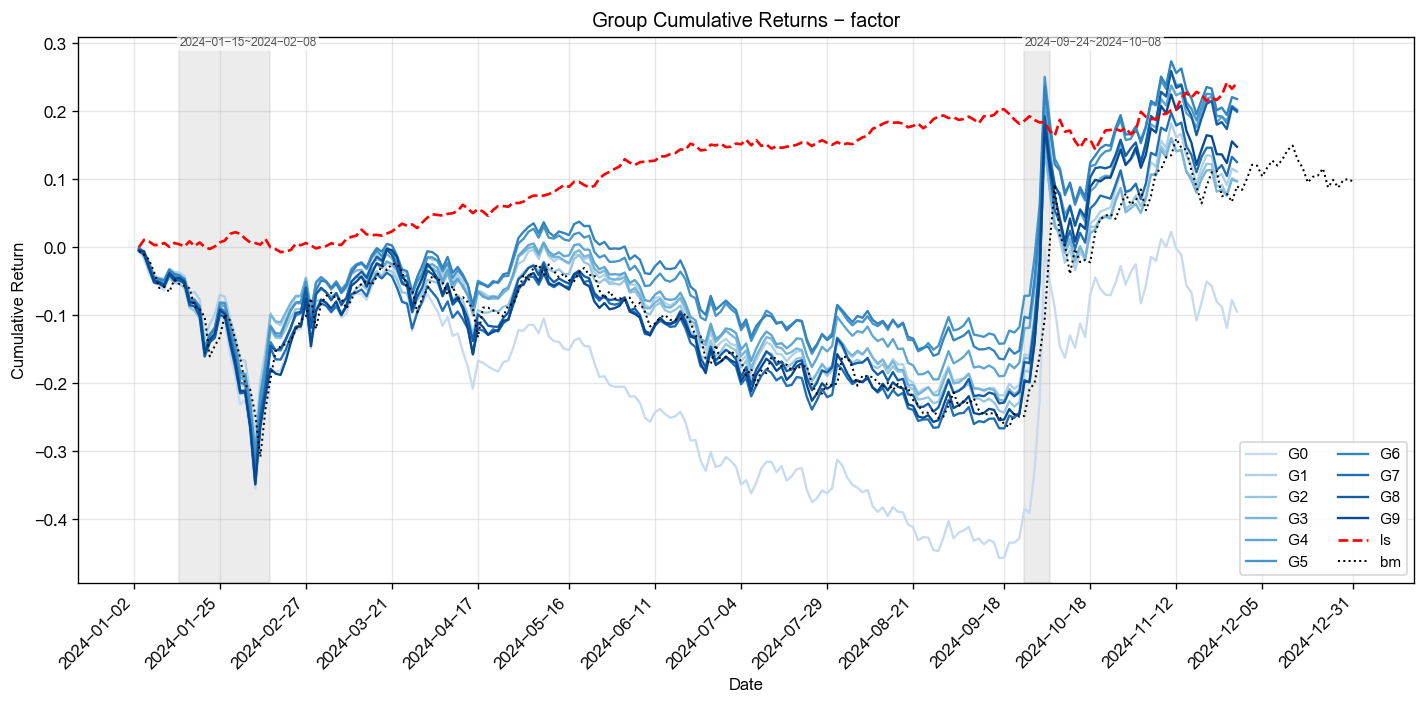
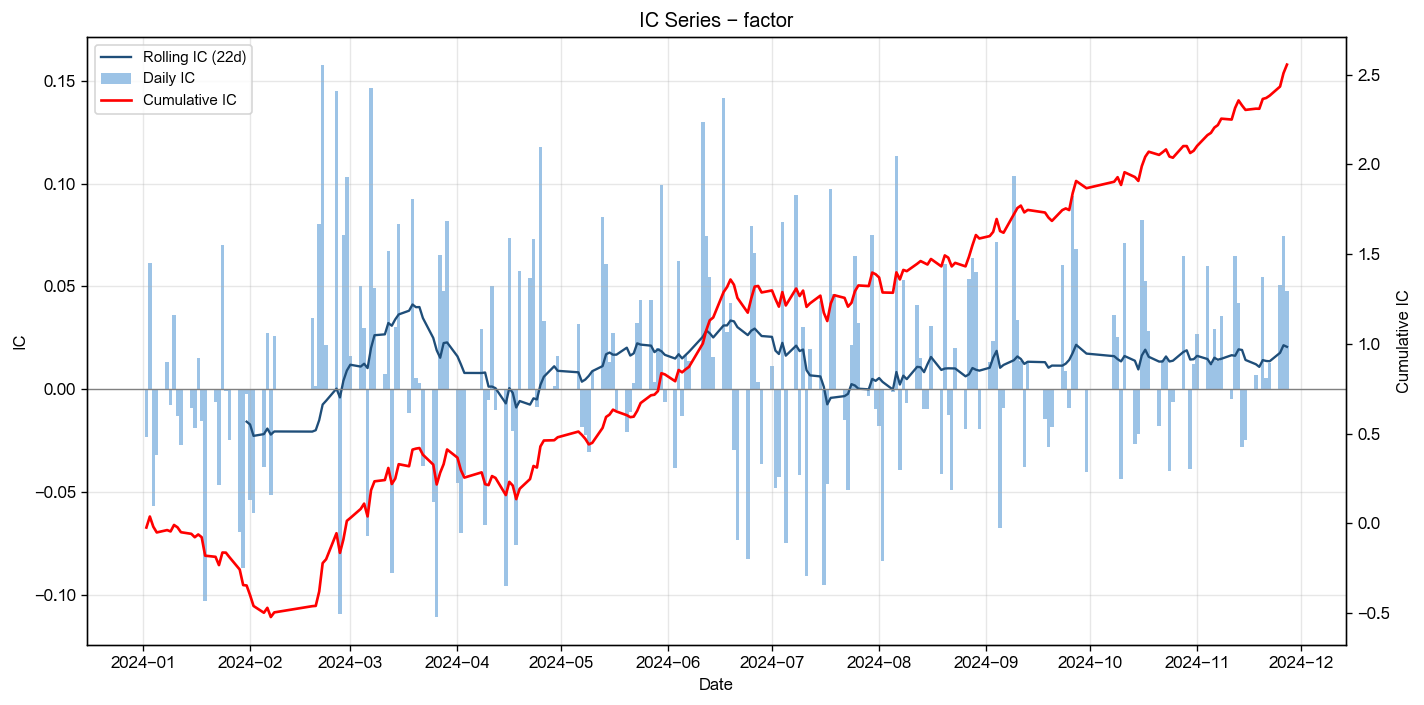
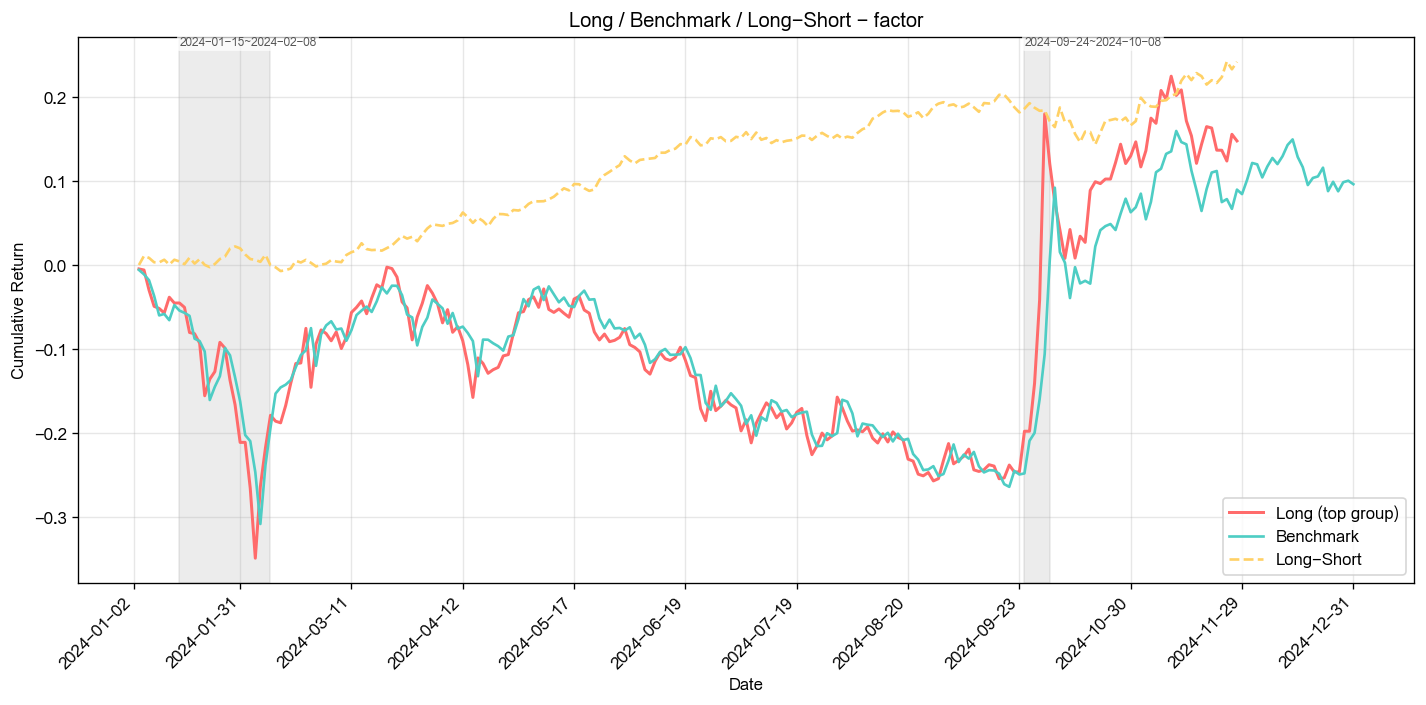
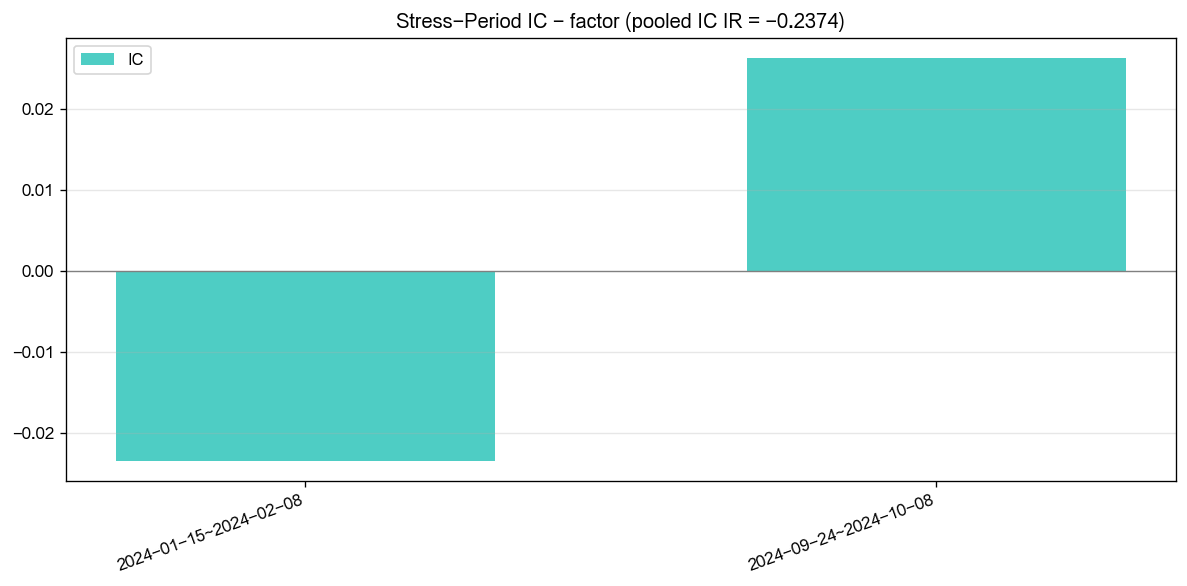
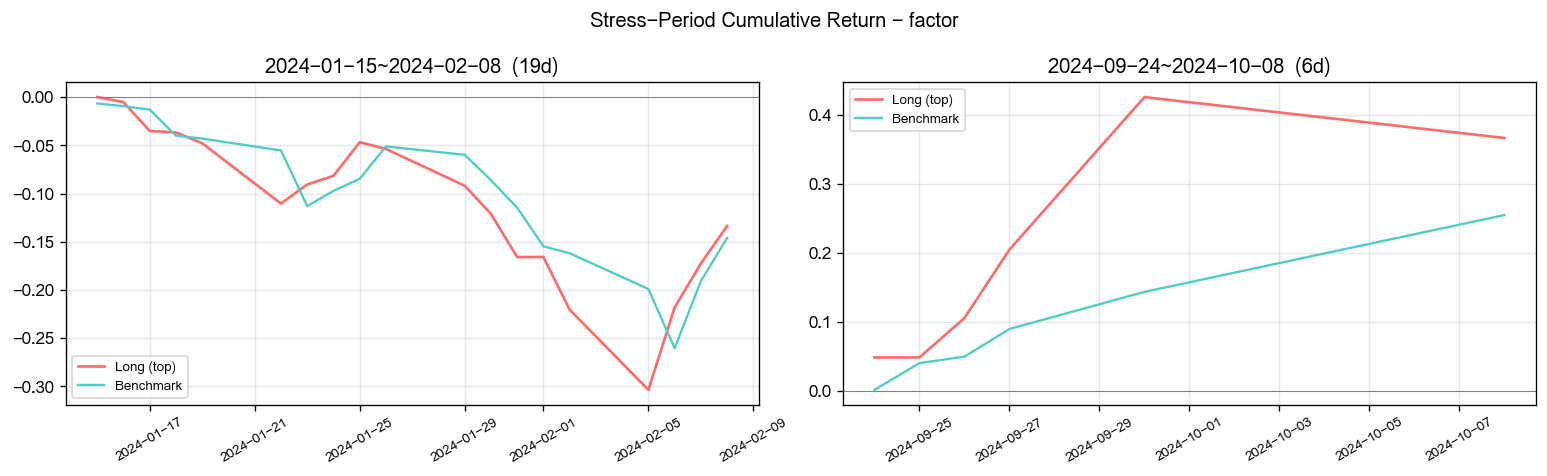

[2026-07-13 09:39:46] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-13 09:39:47] [warning  ] 返回的Outputs实例(size=35135173) 大于 64K, 将不会被缓存
[2026-07-13 09:39:47] [info     ] bigalpha_eval.v4 运行完成 [13.083s].


In [2]:
# 评估 (平台评估模块调用必须在 notebook 中)
from bigmodule import M
result = M.bigalpha_eval._latest(factor_data=score_data, show=True)